# Utils for visualizing demos

## RGBD visualization

In [26]:
# Load demos

import h5py
from mani_skill.utils.io_utils import load_json

# Load the trajectory data from the .h5 file. Demonstrations are versioned and thus saved to "demos/<version>/..."
traj_path = f"demos/PegInsertionSide-v1/motionplanning/trajectory.rgbd.pd_joint_pos.cpu.h5"
# You can also replace the above path with the trajectory you just recorded (./tmp/trajectory.h5)
h5_file = h5py.File(traj_path, "r")

# Load associated json
json_path = traj_path.replace(".h5", ".json")
json_data = load_json(json_path)

episodes = json_data["episodes"] # meta data of each episode
env_info = json_data["env_info"]
env_id = env_info["env_id"]
env_kwargs = env_info["env_kwargs"]

print("env_id:", env_id)
print("env_kwargs:", env_kwargs)
print("#episodes:", len(episodes))

env_id: PegInsertionSide-v1
env_kwargs: {'obs_mode': 'rgbd', 'control_mode': 'pd_joint_pos', 'render_mode': 'rgb_array', 'reward_mode': None, 'sensor_configs': {'shader_pack': 'default'}, 'human_render_camera_configs': {'shader_pack': 'default'}, 'viewer_camera_configs': {'shader_pack': 'default'}, 'sim_backend': 'auto', 'shader_dir': 'default'}
#episodes: 5


In [27]:
# Print demo structure

traj_id = "traj_2"
traj_h5 = h5_file[traj_id]
def print_h5py_structure(traj_h5, prefix=""):
    for key in traj_h5:
        if isinstance(traj_h5[key], h5py.Group):
            print_h5py_structure(traj_h5[key], prefix=prefix + "/" + key)
        else:
            print(prefix + "/" + key, traj_h5[key].shape, traj_h5[key].dtype)

print_h5py_structure(traj_h5)

/obs/agent/qpos (202, 9) float32
/obs/agent/qvel (202, 9) float32
/obs/extra/tcp_pose (202, 7) float32
/obs/sensor_param/base_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/base_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/base_camera/intrinsic_cv (202, 3, 3) float32
/obs/sensor_param/hand_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/hand_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/hand_camera/intrinsic_cv (202, 3, 3) float32
/obs/sensor_data/base_camera/depth (202, 128, 128, 1) int16
/obs/sensor_data/base_camera/rgb (202, 128, 128, 3) uint8
/obs/sensor_data/hand_camera/depth (202, 128, 128, 1) int16
/obs/sensor_data/hand_camera/rgb (202, 128, 128, 3) uint8
/actions (201, 8) float32
/terminated (201,) bool
/truncated (201,) bool
/success (201,) bool
/env_states/actors/table-workspace (202, 13) float32
/env_states/actors/peg (202, 13) float32
/env_states/actors/box_with_hole (202, 13) float32
/env_states/articulations/panda_wristcam (20

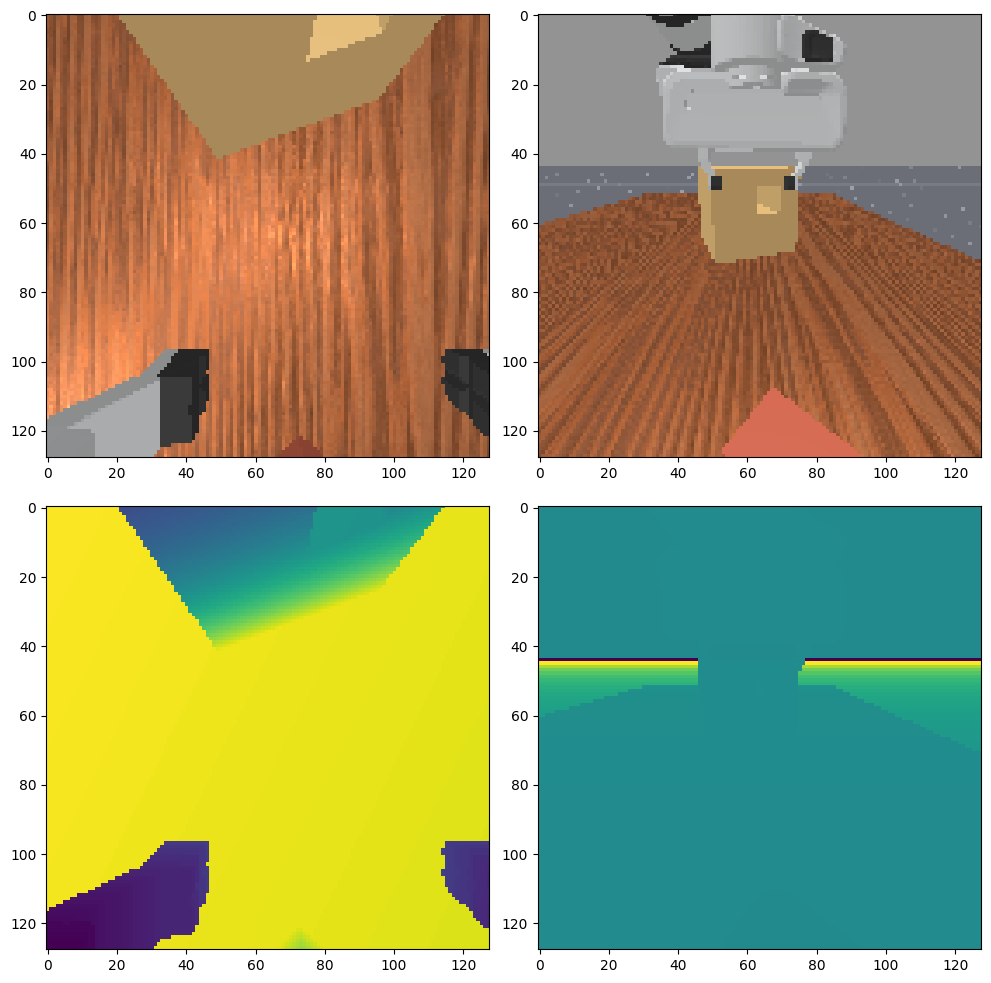

In [29]:
# 2 views
import matplotlib.pyplot as plt
import numpy as np

hand_data = traj_h5["obs"]["sensor_data"]["hand_camera"]
base_data = traj_h5["obs"]["sensor_data"]["base_camera"]
fr_ids = [10]  # List of frame IDs

for fr_id in fr_ids:
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    axs[0, 0].imshow(hand_data["rgb"][fr_id])
    # axs[0, 0].set_title(f'Hand Camera RGB {fr_id}')
    axs[1, 0].imshow(hand_data["depth"][fr_id])
    # axs[0, 1].set_title(f'Hand Camera Depth {fr_id}')
    
    axs[0, 1].imshow(base_data["rgb"][fr_id])
    # axs[1, 0].set_title(f'Base Camera RGB {fr_id}')
    axs[1, 1].imshow(base_data["depth"][fr_id])
    # axs[1, 1].set_title(f'Base Camera Depth {fr_id}')

    plt.tight_layout()
    plt.show()

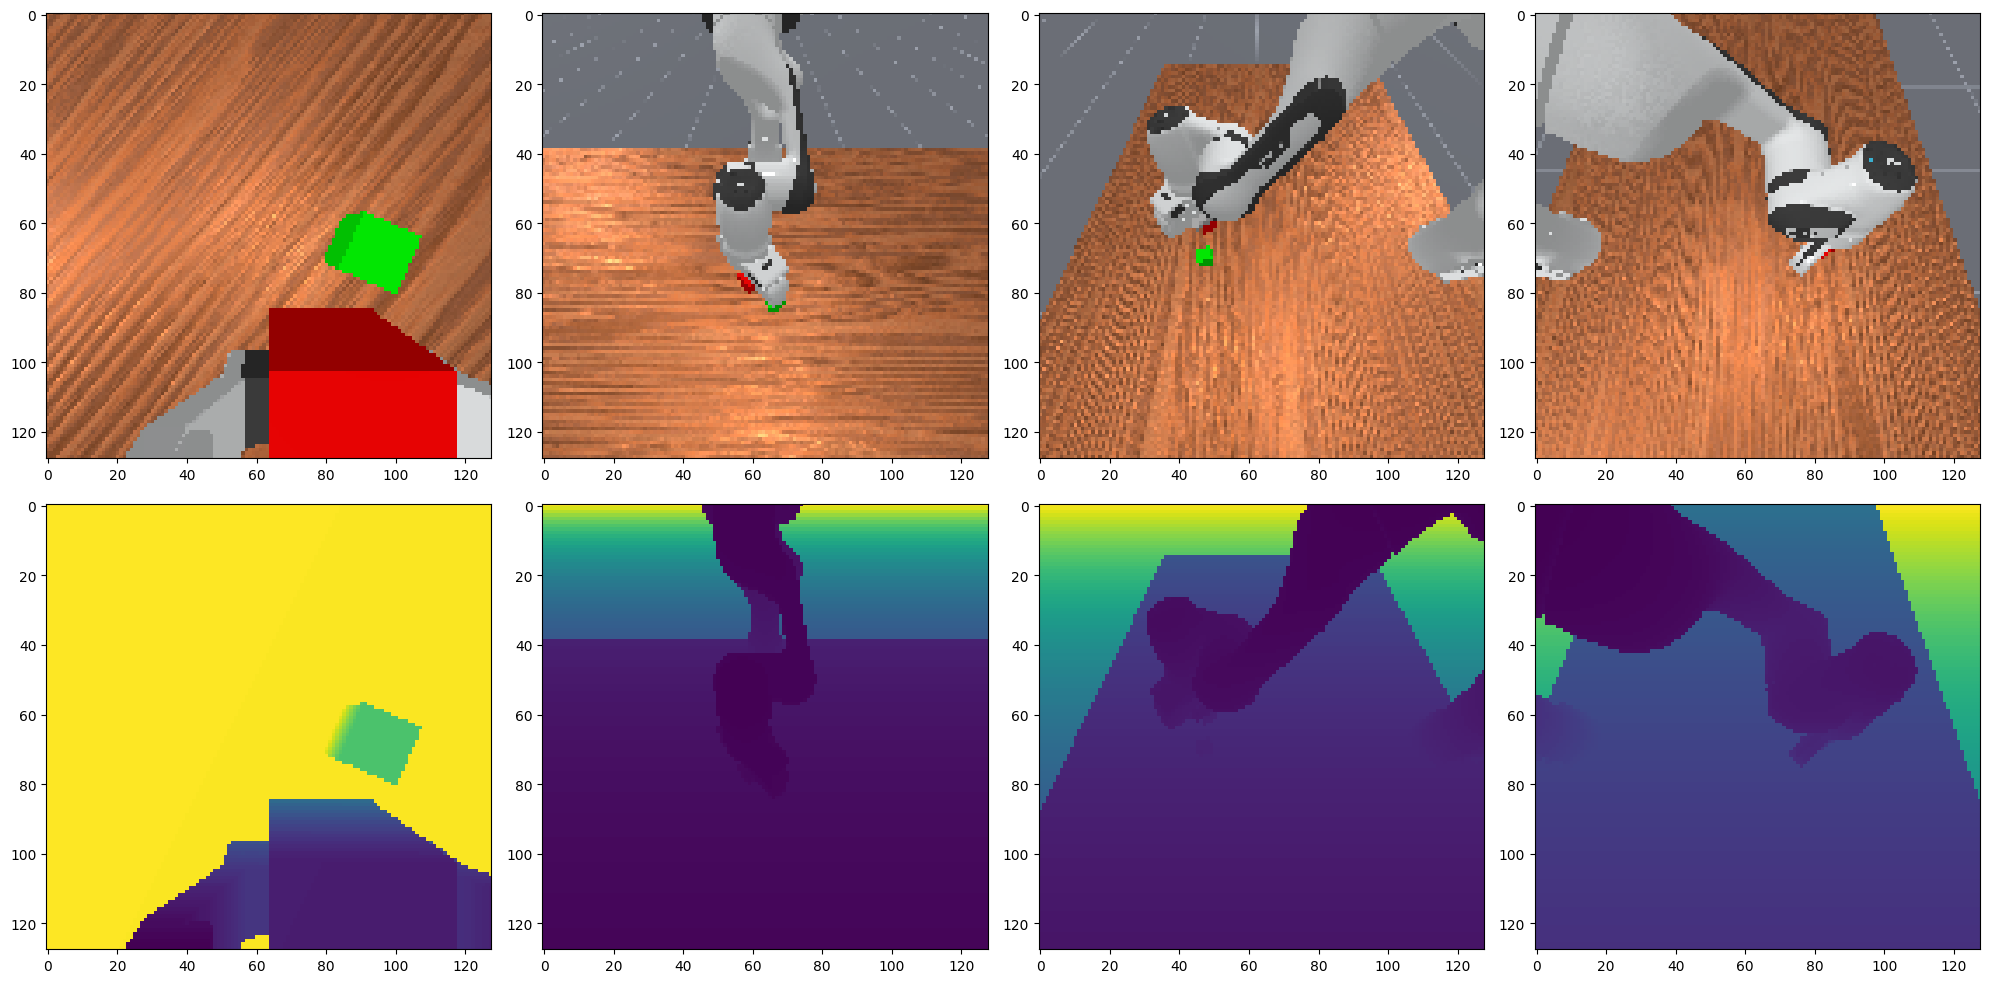

In [6]:
# 4 views
import matplotlib.pyplot as plt
import numpy as np

hand_data = traj_h5["obs"]["sensor_data"]["hand_camera"]
base_data = traj_h5["obs"]["sensor_data"]["base_camera"]
ls_data = traj_h5["obs"]["sensor_data"]["left_shoulder_camera"]
rs_data = traj_h5["obs"]["sensor_data"]["right_shoulder_camera"]
fr_ids = [72]  # List of frame IDs

for fr_id in fr_ids:
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))

    axs[0, 0].imshow(hand_data["rgb"][fr_id])
    # axs[0, 0].set_title(f'Hand Camera RGB {fr_id}')
    axs[1, 0].imshow(hand_data["depth"][fr_id])
    # axs[1, 0].set_title(f'Hand Camera Depth {fr_id}')
    
    axs[0, 1].imshow(base_data["rgb"][fr_id])
    # axs[0, 1].set_title(f'Base Camera RGB {fr_id}')
    axs[1, 1].imshow(base_data["depth"][fr_id])
    # axs[1, 1].set_title(f'Base Camera Depth {fr_id}')
    
    axs[0, 2].imshow(ls_data["rgb"][fr_id])
    # axs[0, 2].set_title(f'Left Shoulder Camera RGB {fr_id}')
    axs[1, 2].imshow(ls_data["depth"][fr_id])
    # axs[1, 2].set_title(f'Left Shoulder Camera Depth {fr_id}')
    
    axs[0, 3].imshow(rs_data["rgb"][fr_id])
    # axs[0, 3].set_title(f'Right Shoulder Camera RGB {fr_id}')
    axs[1, 3].imshow(rs_data["depth"][fr_id])
    # axs[1, 3].set_title(f'Right Shoulder Camera Depth {fr_id}')

    plt.tight_layout()
    plt.show()

## Voxel visualization


In [7]:
# Load demos

import h5py
from mani_skill.utils.io_utils import load_json

# Load the trajectory data from the .h5 file. Demonstrations are versioned and thus saved to "demos/<version>/..."
traj_path = f"demos/PegInsertionSide-v1/motionplanning/mv/trajectory.pointcloud.pd_joint_pos.cpu.h5"
# You can also replace the above path with the trajectory you just recorded (./tmp/trajectory.h5)
h5_file = h5py.File(traj_path, "r")

# Load associated json
json_path = traj_path.replace(".h5", ".json")
json_data = load_json(json_path)

episodes = json_data["episodes"] # meta data of each episode
env_info = json_data["env_info"]
env_id = env_info["env_id"]
env_kwargs = env_info["env_kwargs"]

print("env_id:", env_id)
print("env_kwargs:", env_kwargs)
print("#episodes:", len(episodes))

env_id: PegInsertionSide-v1
env_kwargs: {'obs_mode': 'pointcloud', 'control_mode': 'pd_joint_pos', 'render_mode': 'rgb_array', 'reward_mode': None, 'sensor_configs': {'shader_pack': 'default'}, 'human_render_camera_configs': {'shader_pack': 'default'}, 'viewer_camera_configs': {'shader_pack': 'default'}, 'sim_backend': 'auto', 'shader_dir': 'default'}
#episodes: 5


In [8]:
# Print demo structure
traj_id = "traj_2"
traj_h5 = h5_file[traj_id]
def print_h5py_structure(traj_h5, prefix=""):
    for key in traj_h5:
        if isinstance(traj_h5[key], h5py.Group):
            print_h5py_structure(traj_h5[key], prefix=prefix + "/" + key)
        else:
            print(prefix + "/" + key, traj_h5[key].shape, traj_h5[key].dtype)

print_h5py_structure(traj_h5)

/obs/agent/qpos (202, 9) float32
/obs/agent/qvel (202, 9) float32
/obs/extra/tcp_pose (202, 7) float32
/obs/sensor_param/base_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/base_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/base_camera/intrinsic_cv (202, 3, 3) float32
/obs/sensor_param/left_shoulder_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/left_shoulder_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/left_shoulder_camera/intrinsic_cv (202, 3, 3) float32
/obs/sensor_param/right_shoulder_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/right_shoulder_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/right_shoulder_camera/intrinsic_cv (202, 3, 3) float32
/obs/sensor_param/hand_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/hand_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/hand_camera/intrinsic_cv (202, 3, 3) float32
/obs/pointcloud/xyzw (202, 65536, 4) float32
/obs/pointcloud/rgb (202, 65536, 3) uin

tensor(3571)
Min values per coordinate: tensor([-0.7390, -1.1936, -0.0018,  1.0000])
Max values per coordinate: tensor([1.5000, 1.5000, 1.5000, 1.0000])
Second largest unique values per coordinate: tensor([0.4670, 1.1847, 0.5415, 1.0000])
tensor([[[ 0.1529,  0.1529,  0.1529],
         [ 0.1529,  0.1529,  0.1529],
         [ 0.1529,  0.1529,  0.1529],
         ...,
         [ 0.3490, -0.1843, -0.4980],
         [ 0.2235, -0.2471, -0.5294],
         [-0.0824, -0.4588, -0.6784]]])
tensor([[[ 1.5000e+00,  1.5000e+00,  1.5000e+00],
         [ 1.5000e+00,  1.5000e+00,  1.5000e+00],
         [ 1.5000e+00,  1.5000e+00,  1.5000e+00],
         ...,
         [ 2.0302e-01, -1.9837e-01,  1.4919e-04],
         [ 2.0702e-01, -1.9823e-01,  8.7276e-05],
         [ 2.1102e-01, -1.9810e-01,  2.5347e-05]]])
torch.Size([1, 100, 100, 100, 10])
torch.Size([10, 100, 100, 100])


/home/nan/Desktop/peract/voxel/voxel_grid.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._coord_bounds = torch.tensor(coord_bounds, dtype=torch.float,


(480, 640, 3)


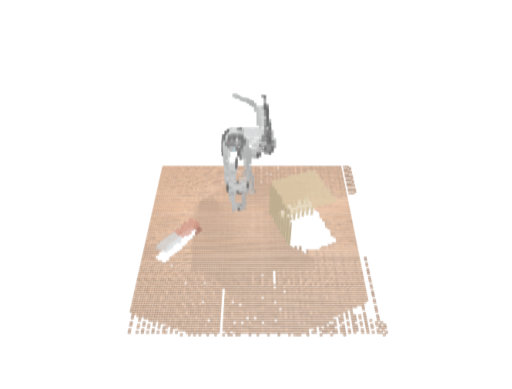

In [10]:
from helpers.utils import visualise_voxel
from voxel.voxel_grid import VoxelGrid
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

num_cameras = len(traj_h5["obs"]["sensor_param"])
image_resolution = [128, 128]
coordinate_bounds = np.array([ -0.4, -0.4, -0.4, 0.5, 0.5, 0.5 ]) 
# coordinate_bounds = np.array([ -1, -1, -1, 1, 1, 1 ]) 
coordinate_bounds = torch.from_numpy(coordinate_bounds)
voxel_size = 100
voxel_feature_size = 3
batch_size = 1
frid = 10

pcd_flat = traj_h5["obs"]["pointcloud"]["xyzw"][frid]
# pcd_flat = pcd_flat[..., :3]
# pcd_flat = pcd_flat[None, ...]
# pcd_flat = torch.from_numpy(pcd_flat)
rgb_flat = traj_h5["obs"]["pointcloud"]["rgb"][frid]
# rgb_flat = rgb_flat[None, ...]
# rgb_flat = torch.from_numpy(rgb_flat)
seg = traj_h5["obs"]["pointcloud"]["segmentation"][frid]

def norm_rgb_(x):
    return (x.float() / 255.0) * 2.0 - 1.0

def print_pcd_min_max(pcd):
    min_vals = pcd.min(dim=0).values
    max_vals = pcd.max(dim=0).values
    
    second_max_vals = []
    
    for i in range(pcd.shape[1]):  # Iterate over each dimension
        unique_vals = torch.unique(pcd[:, i])  # Get unique values in the dimension
        sorted_vals, _ = torch.sort(unique_vals, descending=True)  # Sort in descending order
        
        if len(sorted_vals) > 1:
            second_max_vals.append(sorted_vals[1])  # Second largest unique value
        else:
            second_max_vals.append(sorted_vals[0])  # Fallback if all values are identical

    second_max_vals = torch.stack(second_max_vals)  # Convert list to tensor
    
    print(f"Min values per coordinate: {min_vals}")
    print(f"Max values per coordinate: {max_vals}")
    print(f"Second largest unique values per coordinate: {second_max_vals}")

def preprocess_maniskill_inputs(coordinate_bounds, pcd, rgb, seg):
    # convertions
    pcd = pcd[None, ...]
    pcd = torch.from_numpy(pcd)
    rgb = rgb[None, ...]
    rgb = torch.from_numpy(rgb)
    rgb = norm_rgb_(rgb)
    seg = seg[None, ...]
    seg = torch.from_numpy(seg)

    # clamp w=0 points outside the scene bounds
    bb_maxs = coordinate_bounds[3:6]
    bb_maxs = bb_maxs.to(torch.float)
    out_indices = (pcd[..., 3] == 0)
    print(torch.sum(out_indices))
    pcd[out_indices] = torch.cat([bb_maxs + 1, torch.tensor([1], device="cpu")])

    # clamp floor points outside the scene bounds
    floor_id = 17
    floor_indices = (seg[..., 0] == floor_id)
    pcd[floor_indices] = torch.cat([bb_maxs + 1, torch.tensor([1], device="cpu")])

    # dehomogeneize
    print_pcd_min_max(pcd[0])
    pcd = pcd[..., :3] / pcd[..., 3].unsqueeze(-1)
    return rgb, pcd

rgb_flat, pcd_flat = preprocess_maniskill_inputs(coordinate_bounds, pcd_flat, rgb_flat, seg)
print(rgb_flat)
print(pcd_flat)

voxelizer = VoxelGrid(
        coord_bounds=coordinate_bounds,
        voxel_size=voxel_size,
        batch_size=batch_size,
        device="cuda",
        feature_size=voxel_feature_size,
        max_num_coords=np.prod(image_resolution) * num_cameras
        )


# construct voxel grid
voxel_grid = voxelizer.coords_to_bounding_voxel_grid(
    pcd_flat, coord_features=rgb_flat, coord_bounds=coordinate_bounds)
print(voxel_grid.shape)
voxel_grid = voxel_grid.permute(0, 4, 1, 2, 3).detach()
voxel_grid = voxel_grid[0]
print(voxel_grid.shape)
voxel_grid = voxel_grid.cpu().numpy()

# render voxel image
# print(voxel_grid.shape)
grid_img = transforms.ToTensor()(visualise_voxel(voxel_grid))
grid_img = grid_img.cpu().numpy()
# c, h, w = grid_img.shape
# print(grid_img.shape)
grid_img = grid_img.transpose(1, 2, 0) 
to_pil = transforms.ToPILImage()
grid_img_save = to_pil(grid_img)
grid_img_save.save("useless/voxel.png")
print(grid_img.shape)
# print(grid_img)

# show image
plt.imshow(grid_img)
plt.axis('off')  # Hide axes for better visualization
plt.show()


## Point Cloud Visualization

In [11]:
# Load demos

import h5py
from mani_skill.utils.io_utils import load_json

# Load the trajectory data from the .h5 file. Demonstrations are versioned and thus saved to "demos/<version>/..."
traj_path = f"demos/PegInsertionSide-v1/motionplanning/mv/trajectory.pointcloud.pd_joint_pos.cpu.h5"
# You can also replace the above path with the trajectory you just recorded (./tmp/trajectory.h5)
h5_file = h5py.File(traj_path, "r")

# Load associated json
json_path = traj_path.replace(".h5", ".json")
json_data = load_json(json_path)

episodes = json_data["episodes"] # meta data of each episode
env_info = json_data["env_info"]
env_id = env_info["env_id"]
env_kwargs = env_info["env_kwargs"]

print("env_id:", env_id)
print("env_kwargs:", env_kwargs)
print("#episodes:", len(episodes))

env_id: PegInsertionSide-v1
env_kwargs: {'obs_mode': 'pointcloud', 'control_mode': 'pd_joint_pos', 'render_mode': 'rgb_array', 'reward_mode': None, 'sensor_configs': {'shader_pack': 'default'}, 'human_render_camera_configs': {'shader_pack': 'default'}, 'viewer_camera_configs': {'shader_pack': 'default'}, 'sim_backend': 'auto', 'shader_dir': 'default'}
#episodes: 5


In [12]:
# Print demo structure
traj_id = "traj_2"
traj_h5 = h5_file[traj_id]
def print_h5py_structure(traj_h5, prefix=""):
    for key in traj_h5:
        if isinstance(traj_h5[key], h5py.Group):
            print_h5py_structure(traj_h5[key], prefix=prefix + "/" + key)
        else:
            print(prefix + "/" + key, traj_h5[key].shape, traj_h5[key].dtype)

print_h5py_structure(traj_h5)

/obs/agent/qpos (202, 9) float32
/obs/agent/qvel (202, 9) float32
/obs/extra/tcp_pose (202, 7) float32
/obs/sensor_param/base_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/base_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/base_camera/intrinsic_cv (202, 3, 3) float32
/obs/sensor_param/left_shoulder_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/left_shoulder_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/left_shoulder_camera/intrinsic_cv (202, 3, 3) float32
/obs/sensor_param/right_shoulder_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/right_shoulder_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/right_shoulder_camera/intrinsic_cv (202, 3, 3) float32
/obs/sensor_param/hand_camera/extrinsic_cv (202, 3, 4) float32
/obs/sensor_param/hand_camera/cam2world_gl (202, 4, 4) float32
/obs/sensor_param/hand_camera/intrinsic_cv (202, 3, 3) float32
/obs/pointcloud/xyzw (202, 65536, 4) float32
/obs/pointcloud/rgb (202, 65536, 3) uin

In [13]:
def print_pcd_min_max(pcd):
    min_point = pcd.min(axis=0)  # Min values along each axis
    max_point = pcd.max(axis=0)  # Max values along each axis
    
    print(f"Min Point: {min_point}")
    print(f"Max Point: {max_point}")

def show_pointcloud(obs, frid=0):
    import trimesh
    v = obs['pointcloud']['xyzw'][frid, ..., :3]
    seg = obs['pointcloud']['segmentation'][frid, ...]

    # clamp floor points somewhere to not see it
    floor_id = 17
    floor_indices = (seg[..., 0] == floor_id)
    v[floor_indices] = np.array([0,0,0])

    print_pcd_min_max(v)

    cam2world = obs["sensor_param"]["base_camera"]["cam2world_gl"][frid]
    cam2world = cam2world
    camera = trimesh.scene.Camera("camera", (1024, 1024), fov=(np.rad2deg(np.pi/2), np.rad2deg(np.pi/2)))
    s = trimesh.Scene([trimesh.points.PointCloud(v, obs['pointcloud']['rgb'][frid])], camera=camera, camera_transform=cam2world)
    return s.show()

#@markdown Display one of the Pointcloud observations. Make sure you are using `obs_mode="pointcloud"`
show_pointcloud(traj_h5["obs"], frid=10)

Min Point: [-0.739      -1.1935813  -0.00183856]
Max Point: [0.46700004 1.18473    0.54151905]
